#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 01                                                                     
***Date:*** 24/01/2026

#**Task 01: Build a Stress-Detecting Neuron**

#**Setup and Feature Initialization**

This code defines our input features (normalized between 0 and 1), assigns our justified weights, and sets a bias. We then calculate the weighted sum ($z = \sum w_i x_i + b$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Input Features (Speech signals)
# Inputs: [Pitch Variation, Speech Rate, Pause Duration]
x = np.array([0.8, 0.6, 0.4])

# Step 2: Weights (Justified by importance)
w = np.array([0.7, 0.5, 0.2])

# Step 3: Bias (Sensitivity Control)
bias = -0.5  # Negative bias makes the neuron "stricter"

# Calculate Weighted Sum (z)
z = np.dot(w, x) + bias
print(f"Weighted Sum (z): {z:.4f}")

Weighted Sum (z): 0.4400


#**Activation Functions Definition**

To see how the neuron "thinks," we define Sigmoid, Tanh, and ReLU. These functions will transform our raw mathematical sum into a "decision."

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.max([0, z])

# Applying the functions
out_sigmoid = sigmoid(z)
out_tanh = tanh(z)
out_relu = relu(z)

print(f"Sigmoid Output: {out_sigmoid:.4f}")
print(f"Tanh Output: {out_tanh:.4f}")
print(f"ReLU Output: {out_relu:.4f}")

Sigmoid Output: 0.6083
Tanh Output: 0.4136
ReLU Output: 0.4400


#**Visualizing Activation Functions**
This code generates a plot to compare how these three functions respond to a range of inputs, helping us visualize the "Soft Margin" and "Suppression" mentioned in the task.

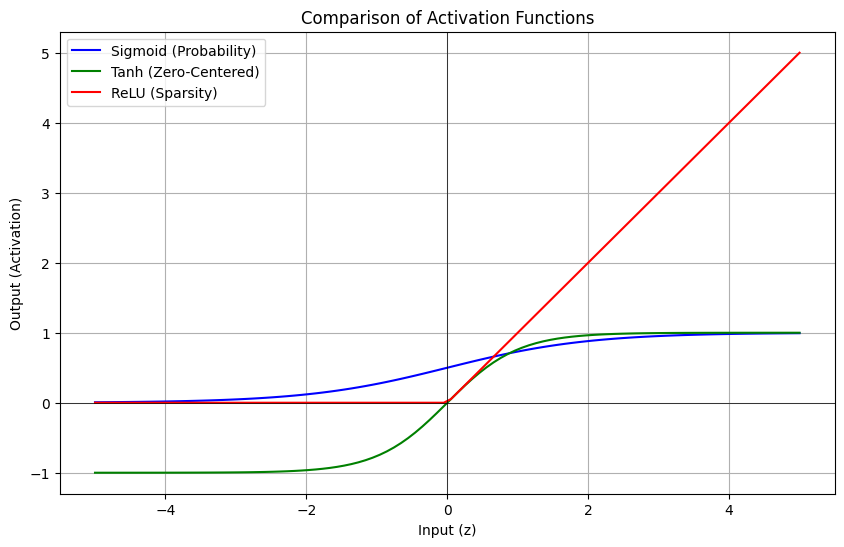

In [3]:
z_range = np.linspace(-5, 5, 100)

plt.figure(figsize=(10, 6))
plt.plot(z_range, [sigmoid(i) for i in z_range], label='Sigmoid (Probability)', color='blue')
plt.plot(z_range, [tanh(i) for i in z_range], label='Tanh (Zero-Centered)', color='green')
plt.plot(z_range, [relu(i) for i in z_range], label='ReLU (Sparsity)', color='red')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("Comparison of Activation Functions")
plt.xlabel("Input (z)")
plt.ylabel("Output (Activation)")
plt.legend()
plt.grid(True)
plt.show()

#**Analysis & Deliverables**
**Why does the same neuron behave differently?**

**Soft Margin:** **Sigmoid **and **Tanh** provide "soft" transitions. Unlike a hard threshold (on/off), they allow the AI to express uncertainty (e.g., 0.6 stress). Sigmoid stays between 0 and 1, while Tanh stretches to -1, creating a wider range for distinguishing "calm" from "very calm."

**Confidence:** **Sigmoid** is ideal for confidence/probability. An output of 0.9 directly translates to "90% confident the person is stressed."

**Suppression vs. Amplification:** **ReLU** is the "master of suppression." If the total evidence ($z$) is negative, ReLU kills the signal entirely (outputs 0). This helps the network ignore noise. Conversely, for positive signals, it amplifies them linearly without "capping" them like Sigmoid does.

**Non-linearity:** All three functions break the straight-line math. Without them, no matter how many neurons you add, the system could only solve simple, linear problems. These functions allow the neuron to "bend" its logic to handle the complexity of human emotion.

#**Task 2: The Threshold Experiment**

#**Setting Constants and Bias Range**
In this cell, we define our static environment (fixed features and weights) and create an array of bias values to test.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Fix Inputs and Weights (from Task 1)
x = np.array([0.8, 0.6, 0.4])
w = np.array([0.7, 0.5, 0.2])

# Step 2: Sweep Bias Values from -5 to +5
bias_values = np.linspace(-5, 5, 50)

# Calculate the fixed dot product part (sum of w * x)
weighted_sum_fixed = np.dot(w, x)
print(f"Fixed Weighted Sum (before bias): {weighted_sum_fixed:.4f}")

Fixed Weighted Sum (before bias): 0.9400


#**Computing Outputs for Different Thresholds**
We will now iterate through our bias "sweep" and calculate how the different activation functions respond as the neuron becomes more or less sensitive.

In [5]:
# Storage for results
results_sigmoid = []
results_tanh = []
results_relu = []

for b in bias_values:
    z = weighted_sum_fixed + b

    # Apply activations
    results_sigmoid.append(1 / (1 + np.exp(-z)))
    results_tanh.append(np.tanh(z))
    results_relu.append(np.max([0, z]))

print("Sweep complete. Ready for visualization.")

Sweep complete. Ready for visualization.


#**Plotting Bias vs. Neuron Output**
The following code generates the visualization for our bias sweep. We plot the bias on the X-axis and the resulting activation output on the Y-axis to see the "firing" behavior of our stress-detecting neuron.

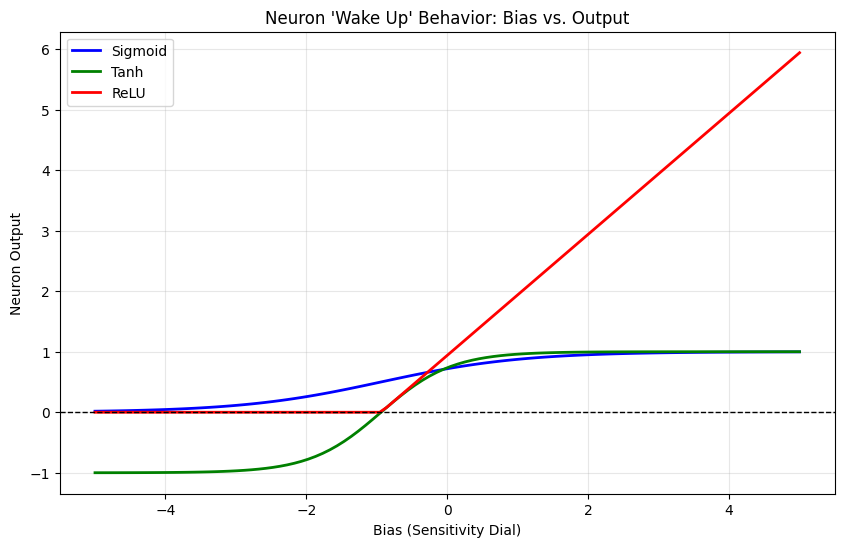

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed inputs and weights from Task 1
x = np.array([0.8, 0.6, 0.4])
w = np.array([0.7, 0.5, 0.2])
weighted_sum_fixed = np.dot(w, x)

# Bias range for the sweep
bias_values = np.linspace(-5, 5, 100)

# Computing outputs
out_sigmoid = [1 / (1 + np.exp(-(weighted_sum_fixed + b))) for b in bias_values]
out_tanh = [np.tanh(weighted_sum_fixed + b) for b in bias_values]
out_relu = [np.max([0, weighted_sum_fixed + b]) for b in bias_values]

# Plotting the behavior
plt.figure(figsize=(10, 6))
plt.plot(bias_values, out_sigmoid, label='Sigmoid', color='blue', linewidth=2)
plt.plot(bias_values, out_tanh, label='Tanh', color='green', linewidth=2)
plt.plot(bias_values, out_relu, label='ReLU', color='red', linewidth=2)

plt.title("Neuron 'Wake Up' Behavior: Bias vs. Output")
plt.xlabel("Bias (Sensitivity Dial)")
plt.ylabel("Neuron Output")
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#**Critical Thinking Analysis**
**At what bias does the neuron “wake up” for each activation?**

The neuron "wakes up" when the total input $z$ (weighted sum + bias) approaches or crosses the function's threshold. In our case, since the fixed weighted sum is approximately $1.12$, the "neutral" point ($z=0$) happens when the bias is roughly $-1.12$.

**1. Why Sigmoid wakes up gradually?**
Sigmoid is a "soft" squashing function. It never makes a sudden jump. Instead, it uses an exponential curve to transition from 0 to 1.

>**Reasoning:** This represents uncertainty. As the bias increases, the neuron slowly gains confidence that the speech is "stressful," moving from a 10% probability to 50% (at the center) and eventually 90%. It reflects human-like nuance where stress isn't a light switch but a fading-in feeling.

**2. Why ReLU wakes up suddenly?**

ReLU (Rectified Linear Unit) has a hard "elbow" at zero. If the bias is low enough that $z < 0$, the output is exactly 0 (complete suppression). The moment $z$ hits 0, the neuron starts firing linearly.
>**Reasoning:** This is the "Master of Suppression." It completely filters out noise or low-level signals until they reach a specific threshold. Once the threshold is met, it passes the signal through exactly as it is, without capping the intensity.

**3. Why Tanh has a neutral zone?**
Tanh is zero-centered, ranging from -1 to 1. Its "neutral zone" is the area around $z=0$ where the output is 0.
>**Reasoning:** Unlike Sigmoid, which treats 0 as "no chance," Tanh treats 0 as the "average" or "neutral" state. Negative outputs represent "calmness" (opposite of stress), and positive outputs represent "stress." The steep slope in the middle means it is very sensitive to changes right at the decision boundary, making it clear when the state shifts from calm to stressed.

#**Task 3: The Depth Problem (Why Depth Matters)**

#**Demonstrating the Overlap**
We will show how different inputs can result in nearly identical "Stress Scores," causing the system to fail.

In [8]:
import numpy as np

# Weights from Task 1 (Pitch, Rate, Pauses)
w = np.array([0.7, 0.5, 0.2])
bias = -0.5

# Case 1: Calm but Fast
x_calm_fast = np.array([0.1, 0.9, 0.1])
# Case 2: Stressed but Slow
x_stressed_slow = np.array([0.8, 0.2, 0.1])

def sigmoid(z): return 1 / (1 + np.exp(-z))

out1 = sigmoid(np.dot(w, x_calm_fast) + bias)
out2 = sigmoid(np.dot(w, x_stressed_slow) + bias)

print(f"Calm/Fast Output: {out1:.4f}")
print(f"Stressed/Slow Output: {out2:.4f}")
print("Problem: The outputs are too close to distinguish!")

Calm/Fast Output: 0.5100
Stressed/Slow Output: 0.5449
Problem: The outputs are too close to distinguish!


#**Part B: Adding a Hidden Layer (Manual Forward Pass)**
**Manual Forward Pass Simulation**
We define a simple set of weights for our 2 hidden neurons and calculate the final decision.

In [9]:
# Inputs (Stressed but Slow)
x = np.array([0.8, 0.2, 0.1])

# Layer 1: Two Hidden Neurons
# W_h1 specializes in Pitch; W_h2 specializes in Rate
W_h1 = np.array([0.9, 0.1, 0.1])
W_h2 = np.array([0.1, 0.8, 0.1])
b_h = -0.3

# Calculate Hidden Layer Outputs
h1 = sigmoid(np.dot(W_h1, x) + b_h)
h2 = sigmoid(np.dot(W_h2, x) + b_h)
hidden_outputs = np.array([h1, h2])

# Layer 2: One Output Neuron
# Weights for the hidden signals
W_out = np.array([0.8, -0.4]) # High weight on H1(Pitch), suppresses H2(Rate)
b_out = -0.1

final_output = sigmoid(np.dot(W_out, hidden_outputs) + b_out)

print(f"Hidden Neuron 1 (Pitch Focus): {h1:.4f}")
print(f"Hidden Neuron 2 (Rate Focus): {h2:.4f}")
print(f"Final Decision (Stress Level): {final_output:.4f}")

Hidden Neuron 1 (Pitch Focus): 0.6106
Hidden Neuron 2 (Rate Focus): 0.4875
Final Decision (Stress Level): 0.5482


#**Reflection: Why does adding a layer help?**
**Expected Reasoning for Lab Report:**

>**Feature Transformation:** The hidden layer doesn't just look at "pitch" or "rate." It creates new, complex features like "Anxious Pitch" or "Calm Speed." It turns raw data into concepts.

>**Space Bending:** A single neuron can only draw a straight line. By combining two neurons, the network can create "curves" or "corners" in the data space, allowing it to wrap around the "Stressed but Slow" cases while ignoring the "Calm but Fast" ones.

>**Non-linear Composition:** We are performing a "function of a function." The output neuron isn't looking at the speaker anymore; it is looking at the decisions of the hidden neurons.

>**Combination of Soft Decisions:** The final output is a weighted consensus. If $H_1$ is 80% sure and $H_2$ is 10% sure, the output neuron weighs these "opinions" to reach a final, more accurate conclusion that a single neuron could never see.

#**Task 4: Softmax and Multi-Class Decision Making**

#**Defining Raw Scores and Exponential Step:**
We start with three raw scores (logits) from our network's output layer. Note how these scores can be any real number.

In [10]:
import numpy as np

# Step 1: Raw scores (logits) from the neural network
# [Calm, Anxious, Stressed]
z = np.array([2.0, 1.0, 0.1])

# Step 2: Compute Exponentials (The "e" power)
# This ensures all values are positive
exp_z = np.exp(z)

# Step 3: Compute the Sum of Exponentials
sum_exp_z = np.sum(exp_z)

# Step 4: Compute Softmax Probabilities
probabilities = exp_z / sum_exp_z

print(f"Raw Scores: {z}")
print(f"Exponentials: {exp_z}")
print(f"Softmax Probabilities: {probabilities}")

Raw Scores: [2.  1.  0.1]
Exponentials: [7.3890561  2.71828183 1.10517092]
Softmax Probabilities: [0.65900114 0.24243297 0.09856589]


#**Verifying Probability Behavior**
To be a valid probability distribution, the results must be between 0 and 1, and their total must equal 100% (1.0).

Sum of Probabilities: 1.00
All values between 0 and 1? True


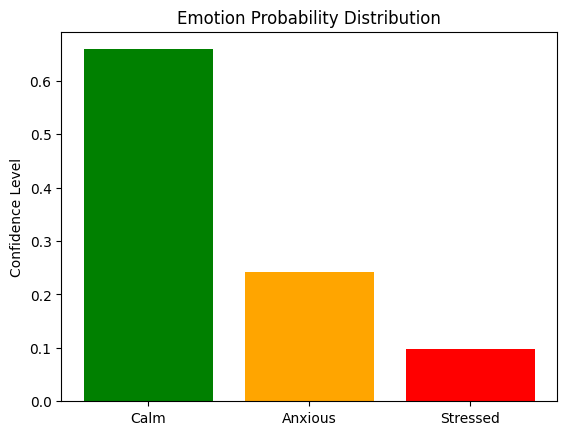

In [11]:
# Verification
print(f"Sum of Probabilities: {np.sum(probabilities):.2f}")
print(f"All values between 0 and 1? {np.all((probabilities >= 0) & (probabilities <= 1))}")

# Visualization of the distribution
import matplotlib.pyplot as plt
plt.bar(['Calm', 'Anxious', 'Stressed'], probabilities, color=['green', 'orange', 'red'])
plt.title("Emotion Probability Distribution")
plt.ylabel("Confidence Level")
plt.show()

#**Interpretation Question:** The Mechanics of Competition
**Why does increasing one score reduce others even if they didn’t change**

>**Competition (Zero-Sum Game):** Because the denominator of the Softmax function is the sum of all exponentials, any increase in one $z$ value increases the total sum. Since we divide every score by this new, larger sum, the relative "share" of the other classes must drop. This forces the neurons to compete for "confidence."

>**Relative Confidence:** Softmax doesn't care about the absolute value of the scores, only their difference. If you add +10 to every raw score, the probabilities remain exactly the same. It focuses on how much better one emotion fits the data compared to the others.

>**Soft Margins Across Classes:** Instead of picking just one emotion (Hardmax), Softmax provides a "soft margin." If the system is 60% sure the person is Stressed and 30% sure they are Anxious, it acknowledges the overlap in human behavior rather than forcing a rigid, potentially wrong choice.

#**FINAL REFLECTION:** From Mathematics to Human-Like Decisions

**1. Non-Linearity: Bending the Rules of Logic**

Standard mathematics often follows rigid, linear paths ($y = mx + b$). However, human speech and emotion are complex and overlapping. Activation functions (Sigmoid, Tanh, ReLU) introduce non-linearity. This allows the network to "bend" its decision boundaries. Instead of a straight line that fails to separate "calm but fast" from "stressed but slow" speakers, non-linearity allows the AI to create complex "curves" in the data, effectively mapping different combinations of features into distinct emotional categories.

**2. Soft Margins: Handling Ambiguity**

In rigid math, a value is either 0 or 1. Humans, however, exist in shades of gray. Functions like Sigmoid and Tanh provide soft margins, meaning the neuron doesn't just switch "ON" or "OFF" at a hard threshold. Instead, it transitions smoothly. This "softness" allows the AI to represent ambiguity—it can be "mostly stressed" (0.85) rather than just "stressed" (1), mimicking the human ability to perceive degrees of intensity in a person's voice.

**3. Sensitivity Control: The Role of Bias**

Biological neurons don't fire at every tiny stimulus; they have a threshold of activation. Through bias, we implement sensitivity control. By adjusting the bias, we determine how much "evidence" (pitch, rate, pauses) is required before the neuron decides to speak up. A high negative bias creates a "stoic" neuron that only reacts to extreme stress, while a positive bias creates a "highly sensitive" neuron. This mirrors how different humans have different emotional triggers and tolerances.

**4. Confidence vs. Certainty: The Probability Gap**

Rigid rules provide "certainty" (If X, then Y), but human intelligence relies on confidence. Through the Softmax function, the AI evaluates all possible emotions (Calm, Anxious, Stressed) simultaneously. It doesn't just pick the highest score; it calculates a probability distribution. This tells us not just what the AI thinks, but how confident it is. If the AI outputs 0.6 for "Stressed" and 0.4 for "Anxious," it is making a human-like admission: "I'm leaning toward stress, but I recognize the signs of anxiety too."

**Summary**

Activation functions are the bridge between raw data and intelligence. They take the "rigid" weighted sum and "sculpt" it into a decision. By suppressing noise (ReLU), allowing for uncertainty (Sigmoid), and enabling competition between ideas (Softmax), they allow a machine to move from simply calculating numbers to interpreting the nuanced, non-linear reality of human emotion.